**# Medical Appointment No-Show Analysis**

**## Project Overview**
Missed medical appointments create scheduling inefficiencies, reduce clinic productivity, and delay care for other patients. This project analyzes patient appointment data to identify factors associated with higher no-show rates.

Data was analyzed using SQL in BigQuery and Python in Google Colab.

**## Tools Used**
- SQL (Google BigQuery)
- Python
- Pandas
- Matplotlib

**## Key Findings**

**### 1. Lead Time Strongly Influences No-Shows**
Appointments scheduled further in advance tend to have higher no-show rates. As the number of days between scheduling and appointment date increases, patients are more likely to miss their appointments.

**### 2. SMS Reminders Do Not Reduce No-Shows**
Surprisingly, patients who received SMS reminders had a higher no-show rate than those who did not. This likely reflects that reminders are sent to higher-risk patients rather than causing missed appointments.

**### 3. Younger Patients Miss More Appointments**
No-show rates were higher among younger adults compared to older patients. Older patients tend to attend scheduled appointments more consistently.

**### 4. Neighborhood Differences Exist**
Some neighborhoods show significantly higher no-show rates than others, suggesting geographic or socioeconomic factors may influence appointment attendance.

**## Conclusion**
The analysis suggests that appointment scheduling practices and patient demographics influence attendance patterns. Healthcare providers may reduce missed appointments by improving reminder strategies and targeting outreach efforts toward high-risk patient groups.

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
!pip install --upgrade google-cloud-bigquery

In [3]:
from google.cloud import bigquery

client = bigquery.Client()

In [4]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(project="first-project-460721")

# Reducing Medical Appointment No-Shows: A Healthcare Operations Analysis

## Project Overview

Missed medical appointments (no-shows) create significant challenges for healthcare systems.
They lead to lost revenue, inefficient use of clinician time, and reduced access to care
for other patients.

This project analyzes patterns in patient appointment attendance to identify factors that
contribute to no-shows and provide insights that healthcare operations teams can use to
reduce missed appointments.

## Dataset

This analysis uses the Medical Appointment No-Shows dataset obtained from Kaggle.

The dataset is stored in BigQuery.

The dataset contains over 100,000 medical appointments and includes information such as:

• Patient demographics  
• Appointment scheduling dates  
• Chronic health conditions  
• SMS reminder notifications  
• Whether the patient attended the appointment

## Stakeholders

The insights from this analysis would be useful for:

• Clinic Operations Managers

• Healthcare Administrators

• Scheduling Departments

• Population Health Teams

## Key Business Questions

1. What is the overall appointment no-show rate?

2. Does the time between scheduling and the appointment date (lead time) affect the likelihood of a patient missing their appointment?

3. Do SMS reminders reduce the probability of patient no-shows?

4. Are certain patient age groups more likely to miss appointments?

5. Are there geographic patterns in no-show rates across neighborhoods?

6. Which neighborhoods show the highest no-show rates and may require targeted intervention?

## Tools Used

• SQL queries performed in BigQuery

• Data exploration documented in Google Colab

• Dashboard visualization created in Looker Studio

# **Data Exploration**

## Data Quality Assessment

In [5]:
query = """
SELECT
  COUNT(*) AS total_rows,
  COUNT(PatientId) AS patientid_not_null,
  COUNT(AppointmentID) AS appointmentid_not_null,
  COUNT(Gender) AS gender_not_null,
  COUNT(ScheduledDay) AS scheduledday_not_null,
  COUNT(AppointmentDay) AS appointmentday_not_null,
  COUNT(Age) AS age_not_null,
  COUNT(Neighbourhood) AS neighbourhood_not_null
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
"""

df = client.query(query).to_dataframe()
df

,total_rows,patientid_not_null,appointmentid_not_null,gender_not_null,scheduledday_not_null,appointmentday_not_null,age_not_null,neighbourhood_not_null
0,110527,110527,110527,110527,110527,110527,110527,110527


In [6]:
query = """
SELECT
  AppointmentID,
  COUNT(*) AS count
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
GROUP BY AppointmentID
HAVING count > 1
"""

df = client.query(query).to_dataframe()
df

,AppointmentID,count


In [7]:
query = """
SELECT
  MIN(Age) AS min_age,
  MAX(Age) AS max_age
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
"""

df = client.query(query).to_dataframe()
df

,min_age,max_age
0,-1,115


Initial data quality checks were conducted to identify missing values, duplicate records, and potential anomalies within the dataset. These checks ensure the reliability of the data before performing further analysis.

## Feature **Engineering**

In [8]:
query = """
SELECT
  *,
  DATE_DIFF(DATE(AppointmentDay), DATE(ScheduledDay), DAY) AS lead_time_days
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
LIMIT 100
"""

df = client.query(query).to_dataframe()
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,lead_time_days
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,False,0
1,5.589980e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,False,0
2,4.262960e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,False,0
3,8.679510e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,False,0
4,8.841190e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.986250e+14,5640307,M,2016-04-29 10:28:54+00:00,2016-04-29 00:00:00+00:00,1,BONFIM,0,0,0,0,0,0,False,0
96,7.937620e+13,5623692,M,2016-04-26 14:28:39+00:00,2016-04-29 00:00:00+00:00,3,BONFIM,0,0,0,0,0,1,False,3
97,5.253340e+12,5565493,F,2016-04-11 09:00:00+00:00,2016-04-29 00:00:00+00:00,35,BONFIM,0,0,0,0,0,1,False,18
98,3.725960e+14,5571906,F,2016-04-12 09:44:42+00:00,2016-04-29 00:00:00+00:00,51,BONFIM,0,0,0,0,0,1,False,17


In [9]:
query = """
SELECT
  MIN(DATE_DIFF(DATE(AppointmentDay), DATE(ScheduledDay), DAY)) AS min_lead_time,
  MAX(DATE_DIFF(DATE(AppointmentDay), DATE(ScheduledDay), DAY)) AS max_lead_time
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
"""

df = client.query(query).to_dataframe()
df

,min_lead_time,max_lead_time
0,-6,179


In [10]:
query = """
SELECT
  DATE_DIFF(DATE(AppointmentDay), DATE(ScheduledDay), DAY) AS lead_time_days,
  COUNT(*) AS appointments
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
GROUP BY lead_time_days
ORDER BY lead_time_days
"""

df = client.query(query).to_dataframe()
df

,lead_time_days,appointments
0,-6,1
1,-1,4
2,0,38563
3,1,5213
4,2,6725
...,...,...
126,155,10
127,162,11
128,169,8
129,176,16


A new variable called Lead Time was created to measure the number of days
between when an appointment was scheduled and when it occurred.

This variable helps evaluate whether longer waiting periods increase the
likelihood of patients missing appointments.

In [11]:
query = """
SELECT
  DATE_DIFF(DATE(AppointmentDay), DATE(ScheduledDay), DAY) AS lead_time_days,
  COUNT(*) AS total_appointments,
  SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) AS total_no_shows,
  ROUND(
    SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) / COUNT(*),
    3
  ) AS no_show_rate
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
GROUP BY lead_time_days
ORDER BY lead_time_days
"""

df = client.query(query).to_dataframe()
df

,lead_time_days,total_appointments,total_no_shows,no_show_rate
0,-6,1,1,1.000
1,-1,4,4,1.000
2,0,38563,1792,0.046
3,1,5213,1113,0.214
4,2,6725,1602,0.238
...,...,...,...,...
126,155,10,6,0.600
127,162,11,2,0.182
128,169,8,1,0.125
129,176,16,6,0.375


Lead Time and Appointment No-Shows
Lead time represents the number of days between when an appointment is scheduled and when it occurs. Longer lead times may increase the likelihood of missed appointments due to scheduling conflicts, forgetfulness, or changes in patient availability.

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
df_clean = df[df["lead_time_days"] <= 90].copy()
df_clean["rolling_rate"] = df_clean["no_show_rate"].rolling(7).mean()

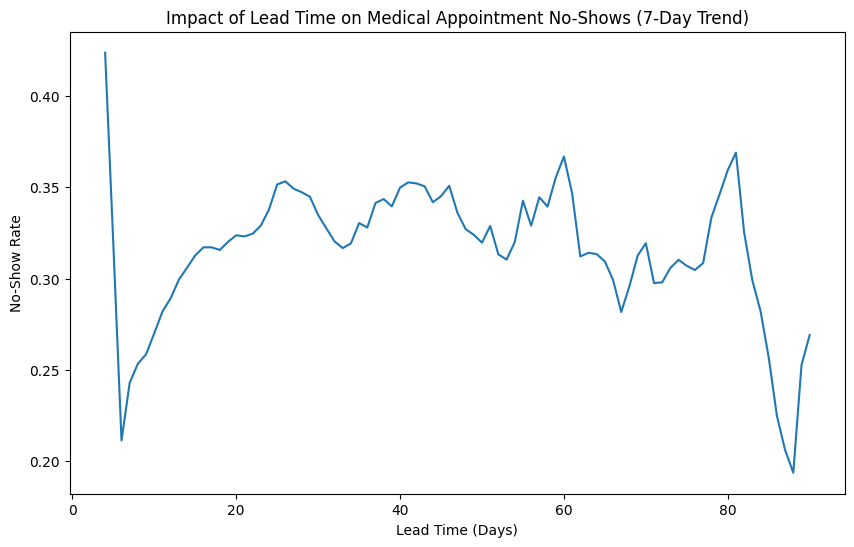

In [14]:
plt.figure(figsize=(10,6))

plt.plot(df_clean["lead_time_days"], df_clean["rolling_rate"])

plt.xlabel("Lead Time (Days)")
plt.ylabel("No-Show Rate")
plt.title("Impact of Lead Time on Medical Appointment No-Shows (7-Day Trend)")

plt.show()


**Insight:**
The analysis shows that no-show rates increase as the lead time between scheduling and the appointment grows. Appointments scheduled within a few days have the lowest no-show rates, while appointments scheduled several weeks in advance experience higher rates of missed visits. This suggests that reducing scheduling delays or implementing reminder systems may help decrease missed appointments.

**SMS Reminder Analysis:**
The analysis compares no-show rates for patients who received an SMS reminder versus those who did not. Interestingly, the data suggests that patients who received SMS reminders still experienced a relatively high no-show rate.

In [15]:
query = """
SELECT
  SMS_received,
  COUNT(*) AS total_appointments,
  SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) AS total_no_shows,
  ROUND(
    SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) / COUNT(*),
    3
  ) AS no_show_rate
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
GROUP BY SMS_received
"""

df_sms = client.query(query).to_dataframe()
df_sms

,SMS_received,total_appointments,total_no_shows,no_show_rate
0,0,75045,12535,0.167
1,1,35482,9784,0.276


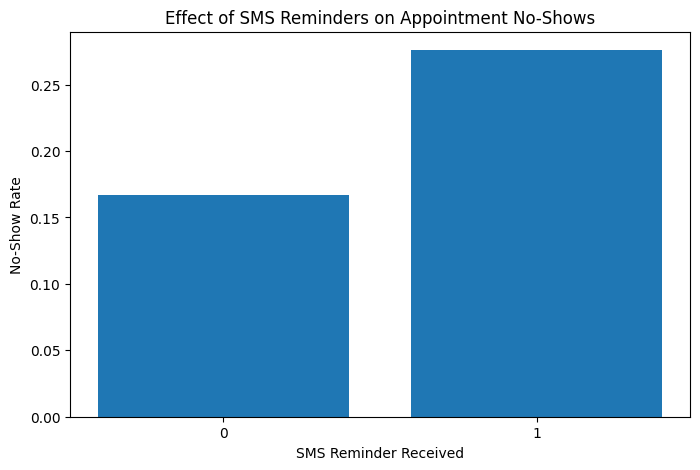

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df_sms["SMS_received"].astype(str), df_sms["no_show_rate"])

plt.xlabel("SMS Reminder Received")
plt.ylabel("No-Show Rate")
plt.title("Effect of SMS Reminders on Appointment No-Shows")

plt.show()

**SMS Reminder Effect:**
Initial analysis suggests that patients who received SMS reminders have a higher no-show rate (27.6%) compared to those who did not receive reminders (16.7%). However, this result likely reflects selection bias. SMS reminders may be disproportionately sent to patients who are already considered at higher risk for missing appointments. Therefore, the higher no-show rate does not necessarily indicate that reminders are ineffective.

In [17]:
query = """
SELECT
  Age,
  COUNT(*) AS total_appointments,
  SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) AS total_no_shows,
  ROUND(
    SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) / COUNT(*),
    3
  ) AS no_show_rate
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
WHERE Age >= 0
GROUP BY Age
ORDER BY Age
"""

df_age = client.query(query).to_dataframe()
df_age

,Age,total_appointments,total_no_shows,no_show_rate
0,0,3539,639,0.181
1,1,2273,415,0.183
2,2,1618,252,0.156
3,3,1513,277,0.183
4,4,1299,282,0.217
...,...,...,...,...
98,98,6,1,0.167
99,99,1,0,0.000
100,100,4,0,0.000
101,102,2,0,0.000


In [18]:
df_age_clean = df_age[df_age["total_appointments"] >= 100]

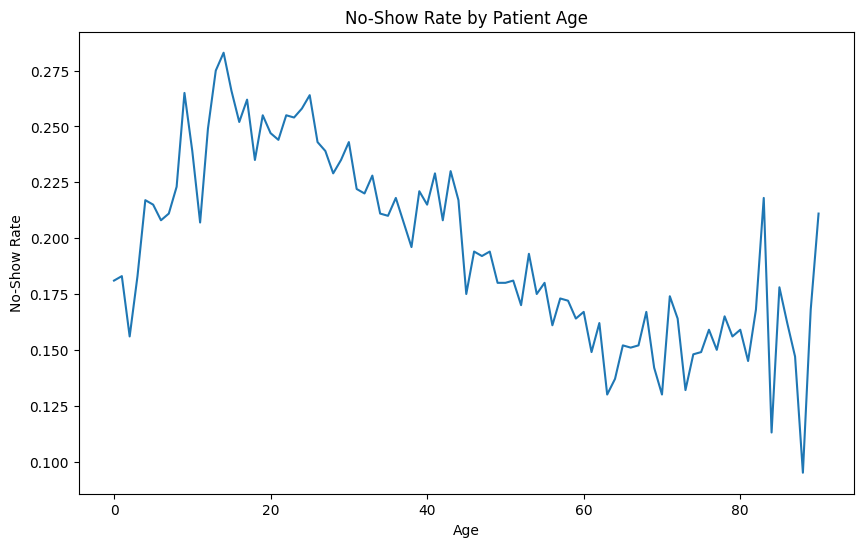

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(df_age_clean["Age"], df_age_clean["no_show_rate"])

plt.xlabel("Age")
plt.ylabel("No-Show Rate")
plt.title("No-Show Rate by Patient Age")

plt.show()

In [20]:
query = """
SELECT
  CASE
    WHEN Age <= 18 THEN '0-18'
    WHEN Age BETWEEN 19 AND 35 THEN '19-35'
    WHEN Age BETWEEN 36 AND 50 THEN '36-50'
    WHEN Age BETWEEN 51 AND 65 THEN '51-65'
    ELSE '65+'
  END AS age_group,

  COUNT(*) AS total_appointments,

  SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) AS total_no_shows,

  ROUND(
    SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) / COUNT(*),
    3
  ) AS no_show_rate

FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`

WHERE Age >= 0

GROUP BY age_group

ORDER BY age_group
"""

df_age_group = client.query(query).to_dataframe()
df_age_group

,age_group,total_appointments,total_no_shows,no_show_rate
0,0-18,28866,6347,0.220
1,19-35,24137,5753,0.238
2,36-50,22100,4492,0.203
3,51-65,22122,3661,0.165
4,65+,13301,2066,0.155


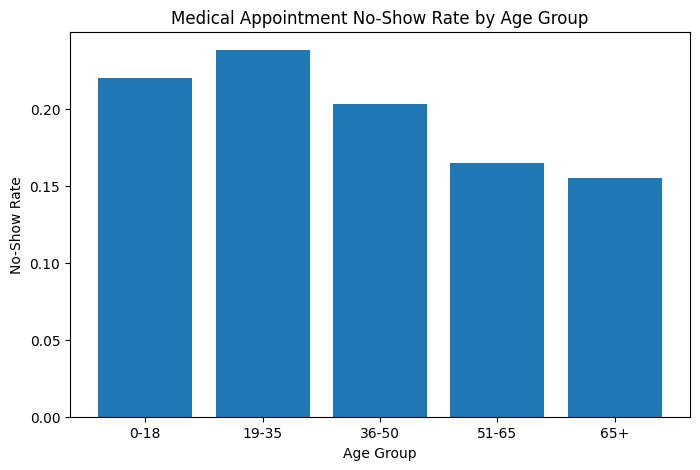

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df_age_group["age_group"], df_age_group["no_show_rate"])

plt.xlabel("Age Group")
plt.ylabel("No-Show Rate")
plt.title("Medical Appointment No-Show Rate by Age Group")

plt.show()

**Age and Appointment Attendance:**
The analysis indicates that younger adults tend to have higher no-show rates compared to older patients. As age increases, the probability of missing an appointment generally decreases. This may reflect differences in schedule stability, healthcare engagement, or perceived importance of medical visits among different age groups.

In [22]:
query = """
SELECT
  Neighbourhood,
  COUNT(*) AS total_appointments,
  SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) AS total_no_shows,
  ROUND(
    SUM(CASE WHEN `No-show` THEN 1 ELSE 0 END) / COUNT(*),
    3
  ) AS no_show_rate
FROM `first-project-460721.Medical_Apointment_No_Shows.No_Shows`
GROUP BY Neighbourhood
HAVING COUNT(*) >= 50
ORDER BY no_show_rate DESC
"""

df_neighborhood = client.query(query).to_dataframe()
df_neighborhood

,Neighbourhood,total_appointments,total_no_shows,no_show_rate
0,SANTOS DUMONT,1276,369,0.289
1,SANTA CECÍLIA,448,123,0.275
2,SANTA CLARA,506,134,0.265
3,ITARARÉ,3514,923,0.263
4,JESUS DE NAZARETH,2853,696,0.244
...,...,...,...,...
71,SANTA MARTHA,3131,496,0.158
72,DO CABRAL,560,88,0.157
73,DE LOURDES,305,47,0.154
74,SOLON BORGES,469,69,0.147


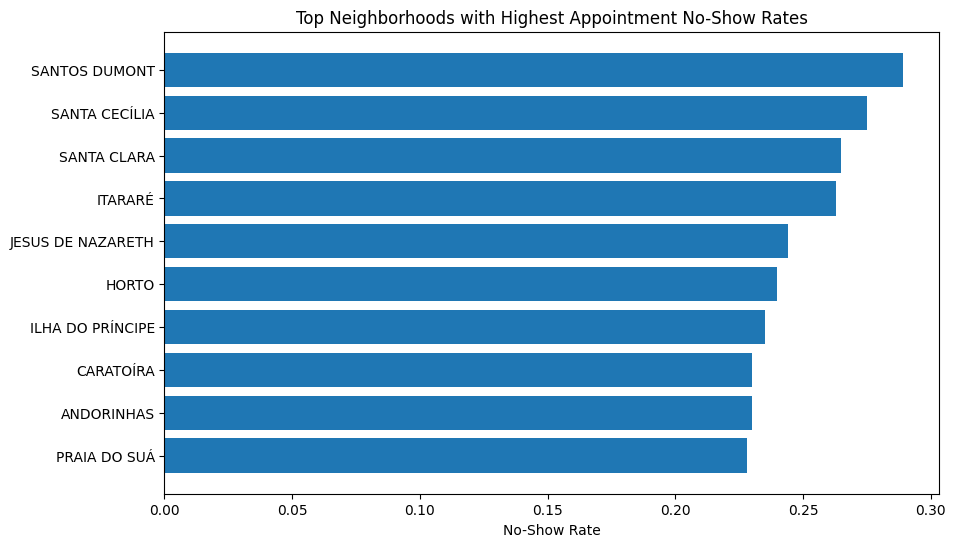

In [23]:
import matplotlib.pyplot as plt

top10 = df_neighborhood.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Neighbourhood"], top10["no_show_rate"])

plt.xlabel("No-Show Rate")
plt.title("Top Neighborhoods with Highest Appointment No-Show Rates")

plt.gca().invert_yaxis()

plt.show()

Operational Recommendations

1. Reduce Long Scheduling Lead Times

Analysis showed that appointments scheduled further in advance have higher no-show rates. Clinics may reduce missed visits by limiting long scheduling gaps when possible or by implementing additional reminders for appointments booked far in advance.

2. Target High-Risk Patient Groups

Younger adult patients showed higher missed appointment rates. Healthcare organizations could improve attendance through targeted reminder strategies such as text messages or digital notifications.

3. Review Effectiveness of SMS Reminder Strategy

Patients who received SMS reminders showed higher no-show rates in the dataset. This likely indicates that reminders are sent to patients already considered high risk. Further analysis could evaluate whether reminder timing or messaging affects attendance.

4. Identify Community Barriers to Care

Some neighborhoods demonstrated higher no-show rates. This may reflect transportation barriers, work schedule conflicts, or other socioeconomic factors. Healthcare providers may benefit from community outreach or flexible scheduling options in these areas.